In [21]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import re
import html
import matplotlib.pyplot as plt
import collections
import os
import tensorflow as tf
import h5py
import pickle

from tensorflow.keras import Input, Model
from tensorflow.keras import layers



gpus = tf.config.list_physical_devices('GPU')
if gpus:
  for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)

# 1. Preprocesamiento de los Datos

## 1.1. Extracción de datos

El primer paso a realizar dentro de un entrenamiento e implementación de un modelo de Red Neuronal es extraer aquellos datos que se van a emplear dentro del entrenamiento del modelo.

En este caso, vamos a importar los datos empleados dentro de la práctica a través de un keras

In [22]:
df = pd.read_csv("news_dataset.csv", quotechar='"')

## 1.2 Previsualizar los datos

In [23]:
df.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


Al ver el contenido de las primeras filas los datos, encontramos 3 columnas:

- Class Index: Tipo de noticia.
- Title: Titulo de la noticia
- Description: Contenido real de la noticia

Ahora vamos a explorar el dataset en busca de cuantos elementos hay en todo el csv y cuantas clases hay en la columna de `Class Index` para hacernos una idea de a cuantas clases no vamos a enfrentar.

In [62]:
df.shape

(119991, 7)

In [25]:
# Ver cuántas noticias hay de cada categoría
df['Class Index'].value_counts()

Class Index
3    30000
4    30000
2    30000
1    30000
Name: count, dtype: int64

Vemos que hay cuatro clases en la columna de Class Index, tambien podemos apreciar que tienen una distribucion homogenea, de 30.000 datos por clase.

Ve

C:\Users\sluis\AppData\Local\Temp\ipykernel_11856\3946130902.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class Index', data=df, palette='viridis')


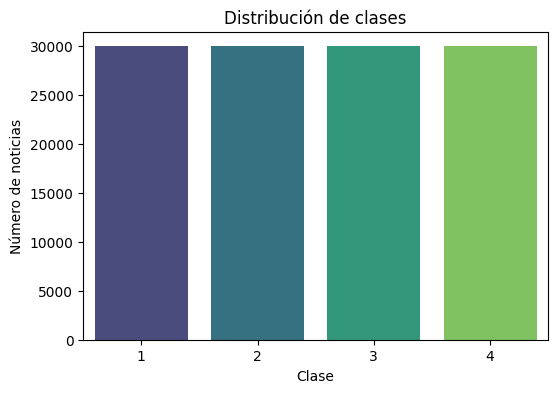

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class Index', data=df, palette='viridis')
plt.title('Distribución de clases')
plt.xlabel('Clase')
plt.ylabel('Número de noticias')
plt.show()

El data set proporcionado consta de 4 grupos de noticias del siguiente tipo:

- 1 -> World (noticias del mundo / política)
- 2 -> Sports (deportes)
- 3 -> Business (ecnomía)
- 4 -> Sci/Tech (ciencia y tecnología)

Despues de una vista general de las clases y que contiene cada una, vamos a visualizar el contenido de las descripciones en busca de anomalias.

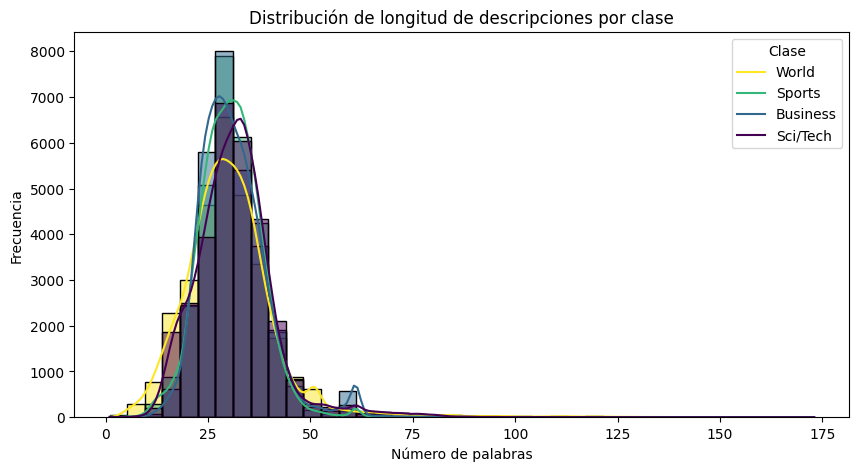

In [28]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='longitud', hue='Class Index', bins=40, kde=True, palette='viridis')
plt.title('Distribución de longitud de descripciones por clase')
plt.xlabel('Número de palabras')
plt.ylabel('Frecuencia')
plt.legend(title='Clase', labels=['World', 'Sports', 'Business', 'Sci/Tech'])
plt.show()

In [29]:
resumen = df.groupby('Class Index')['longitud'].describe()[['mean','std','min','50%','max']]
resumen.index = ['World', 'Sports', 'Business', 'Sci/Tech']
display(resumen.round(2))

,mean,std,min,50%,max
World,31.63,9.85,1.0,31.0,139.0
Sports,31.34,8.58,1.0,30.0,149.0
Business,30.74,7.78,4.0,31.0,131.0
Sci/Tech,30.53,12.21,3.0,29.0,173.0


Aunque hay una distribución balanceada de los datos, al graficar las clases por colores observamos que alguna categoría presenta textos con mayor longitud media. Sin embargo, viendo las estadísticas descriptivas por clase, no encontramos diferencias significativas que justifiquen un tratamiento especial para ninguna de ellas, por lo que continuamos con el dataset completo.

Vamos a seguir el proceso viendo que contenido hay en las filas mas pequeñas donde hay de una a 6 palabras

In [33]:
# Ver exactamente qué contienen esas filas
df[(df['longitud'] >= 1) & (df['longitud'] <= 6)][['Description']].values

array([['&lt;strong&gt;Opinion&lt;/strong&gt; SAP hardly to blame'],
       ['&lt;strong&gt;Competition&lt;/strong&gt; Get those suggestions in'],
       ['&lt;strong&gt;HP World&lt;/strong&gt; Booth intro steals show'],
       ['&lt;strong&gt;HP World&lt;/strong&gt; SAP hell lingers'],
       [' APPLIED MATERIALS INC. &lt;A HREF="http://www.investor.reuters.com/FullQuote.aspx?ticker=AMAT.O target=/stocks/quickinfo/fullquote"&gt;AMAT.O&lt;/A&gt;:'],
       ['&lt;strong&gt;HP World&lt;/strong&gt; Execs try to respond'],
       ['&lt;strong&gt;Opinion&lt;/strong&gt; A chip on the shoulder?'],
       ['&lt;strong&gt;Analysis&lt;/strong&gt; Lost in Space'],
       ['The Associated Press By Ted Bridis'],
       ["&lt;strong&gt;Site Offer&lt;/strong&gt; 30 off 'First-Step' guides"],
       ['&lt;strong&gt;LogoWatch&lt;/strong&gt; Unpleasant, but not fatal'],
       ['&lt;strong&gt;Poll result&lt;/strong&gt; The people have spoken'],
       ["&lt;strong&gt;Exclusive&lt;/strong&gt; WinFS, new 

In [ ]:

df[df['Description'] == '#NAME?'].shape

(0, 4)

Tras visualziar las descripciones nos encontramos algunas en las que hay contenido corrupto que contienen datos como los siguientes:

- "#NAME?"

Estos son errores de excel donde el dato no se ha cargado, como el numero de filas es tan bajo en comparacion al numero de datos que encontramos en el dataset vamos a borrar las filas que contienen ese tipo de datos

In [ ]:
df = df[df['Description'] != '#NAME?'].reset_index(drop=True)

# df = df[(df['longitud'] >= 25) & (df['longitud'] <= 33)].reset_index(drop=True)

Si seguimos analizando las descripciones también nos encontramos descripciones donde hay este tipo de datos:

- Etiquetas HTML residuales
- Puntuación, números, caracteres especiales
- Mezcla de mayúsculas y minúsculas

Necesitamos **normalizar** para que el modelo trate `"Dog"`, `"dog"` y `"DOG"` como la misma palabra.

**Pasos de limpieza:**
1. Convertir a minúsculas
2. Eliminar etiquetas HTML con regex
3. Eliminar todo lo que no sean letras o espacios
4. Eliminar espacios múltiples

In [34]:
def limpiar_texto(texto):
    if not isinstance(texto, str):
        return ''
    texto = texto.lower()
    texto = re.sub(r'\[.*?\]\(.*?\)', '', texto)
    texto = re.sub(r'http\S+|www\.\S+', '', texto)
    texto = re.sub(r'<[^>]+>', ' ', texto)
    texto = texto.replace('\\', ' ')
    texto = re.sub(r'^(reuters|ap|afp)\s*-\s*', '', texto)
    texto = re.sub(r'[^a-záéíóúñü\s]', ' ', texto)
    texto = re.sub(r'\b\w\b', '', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto



# Guardar en columnas nuevas del DataFrame
df['Description_clean'] = df['Description'].apply(limpiar_texto)
df['Title_clean'] = df['Title'].apply(limpiar_texto)

# Combinar título y descripción
df['Texto_completo'] = df['Title_clean'] + ' ' + df['Description_clean']

df[['Title_clean', 'Description_clean', 'Texto_completo']].head(5)

,Title_clean,Description_clean,Texto_completo
0,wall st bears claw back into the black reuters,short sellers wall street dwindling band of ul...,wall st bears claw back into the black reuters...
1,carlyle looks toward commercial aerospace reuters,private investment firm carlyle group which ha...,carlyle looks toward commercial aerospace reut...
2,oil and economy cloud stocks outlook reuters,soaring crude prices plus worries about the ec...,oil and economy cloud stocks outlook reuters s...
3,iraq halts oil exports from main southern pipe...,authorities have halted oil export flows from ...,iraq halts oil exports from main southern pipe...
4,oil prices soar to all time record posing new ...,tearaway world oil prices toppling records and...,oil prices soar to all time record posing new ...


Una vez limpio el texto, necesitamos convertirlo en números para que el modelo pueda procesarlo.
Este proceso tiene dos pasos:

Tokenización: dividir cada texto en una lista de palabras individuales.
Por ejemplo: `"soaring crude prices"` → `['soaring', 'crude', 'prices']`

Vocabulario: construir un diccionario `palabra → ID numérico` con todas las palabras del corpus.
Solo incluimos palabras que aparecen al menos 5 veces (`MIN_FREQ=5`), descartando palabras
muy raras que no tienen suficiente contexto para aprender un buen embedding.

Para poder hacer esto, tenemos que quitar algunas palabras inservibles que van a tener influencia en la selección de tokens. Para eso vamos a crear una lista de palabras las cuales se repiten mucho como their, but, etc. Estas palabras se conocen como **stopwords** y no aportan significado semántico al texto — palabras como artículos, preposiciones, conjunciones y pronombres aparecen en cualquier tipo de noticia independientemente de su categoría, por lo que incluirlas en el vocabulario solo añade ruido al modelo. Además, eliminamos residuos de HTML (`lt`, `gt`, `quot`) y nombres de agencias de noticias (`reuters`, `ap`, `afp`) que tampoco aportan información relevante.

In [38]:
stopwords = {
    'the', 'to', 'of', 'in', 'and', 'on', 'for', 'that', 'with', 'as',
    'at', 'is', 'by', 'it', 'be', 'are', 'was', 'were', 'from', 'an',
    'this', 'have', 'has', 'had', 'but', 'not', 'they', 'he', 'she',
    'we', 'you', 'his', 'her', 'their', 'its', 'our', 'or', 'will',
    'been', 'about', 'which', 'who', 'after', 'also', 'more', 'than',
    'up', 'said', 'would', 'could', 'into', 'over', 'do', 'did', 'out',
    'no', 'if', 'when', 'there', 'all', 'can', 'one', 'two', 'so', 'what',
    'lt', 'gt', 'quot', 'amp',          # restos de HTML
    'reuters', 'ap', 'afp',             # agencias
    'monday', 'tuesday', 'wednesday',   # días
    'thursday', 'friday', 'saturday', 'sunday',
    'us', 'new', 'first', 'year',       # palabras poco informativas
}

def tokenizar(texto):
    return texto.split()

tokens_completo = [tokenizar(t) for t in df['Texto_completo']]

# Filtrar stopwords de los tokens
tokens_completo = [
    [token for token in doc if token not in stopwords]
    for doc in tokens_completo
]

Una vez hecha la limpieza podemos hacer la eleccion de tokens. Vamos a definiar un minimo de frecuencia para no añadir ruido a la tokenizacion. Lo que buscamos con la frecuencia es que solo seleccionemos las palabras que se repiten mas de 5 veces

In [39]:
MIN_FREQ = 5

# Contar frecuencias en el corpus
freq = collections.Counter(token for doc in tokens_completo for token in doc)

print(f'Palabras únicas (sin filtrar): {len(freq):,}')
print(f'Palabras con freq >= {MIN_FREQ}: {sum(1 for f in freq.values() if f >= MIN_FREQ):,}')
print()

# Construir vocabulario: palabra → ID
word2idx = {'<PAD>': 0, '<UNK>': 1}
for palabra, conteo in freq.most_common():
    if conteo >= MIN_FREQ:
        word2idx[palabra] = len(word2idx)

idx2word = {i: w for w, i in word2idx.items()}
VOCAB_SIZE = len(word2idx)

print(f'Tamaño final del vocabulario: {VOCAB_SIZE:,}')
print(f'  (incluye <PAD>=0 y <UNK>=1)')
print()
print('Top 15 palabras más frecuentes:')
for palabra, conteo in freq.most_common(15):
    print(f'  {palabra:<15} freq={conteo:>5}  ID={word2idx.get(palabra, "?")}')

Palabras únicas (sin filtrar): 61,645
Palabras con freq >= 5: 26,719

Tamaño final del vocabulario: 26,721
  (incluye <PAD>=0 y <UNK>=1)

Top 15 palabras más frecuentes:
  world           freq= 8634  ID=2
  company         freq= 7656  ID=3
  oil             freq= 7564  ID=4
  against         freq= 6899  ID=5
  inc             freq= 6853  ID=6
  last            freq= 6548  ID=7
  iraq            freq= 6335  ID=8
  york            freq= 6268  ID=9
  yesterday       freq= 6099  ID=10
  three           freq= 6034  ID=11
  president       freq= 5994  ID=12
  microsoft       freq= 5935  ID=13
  million         freq= 5812  ID=14
  game            freq= 5774  ID=15
  week            freq= 5654  ID=16


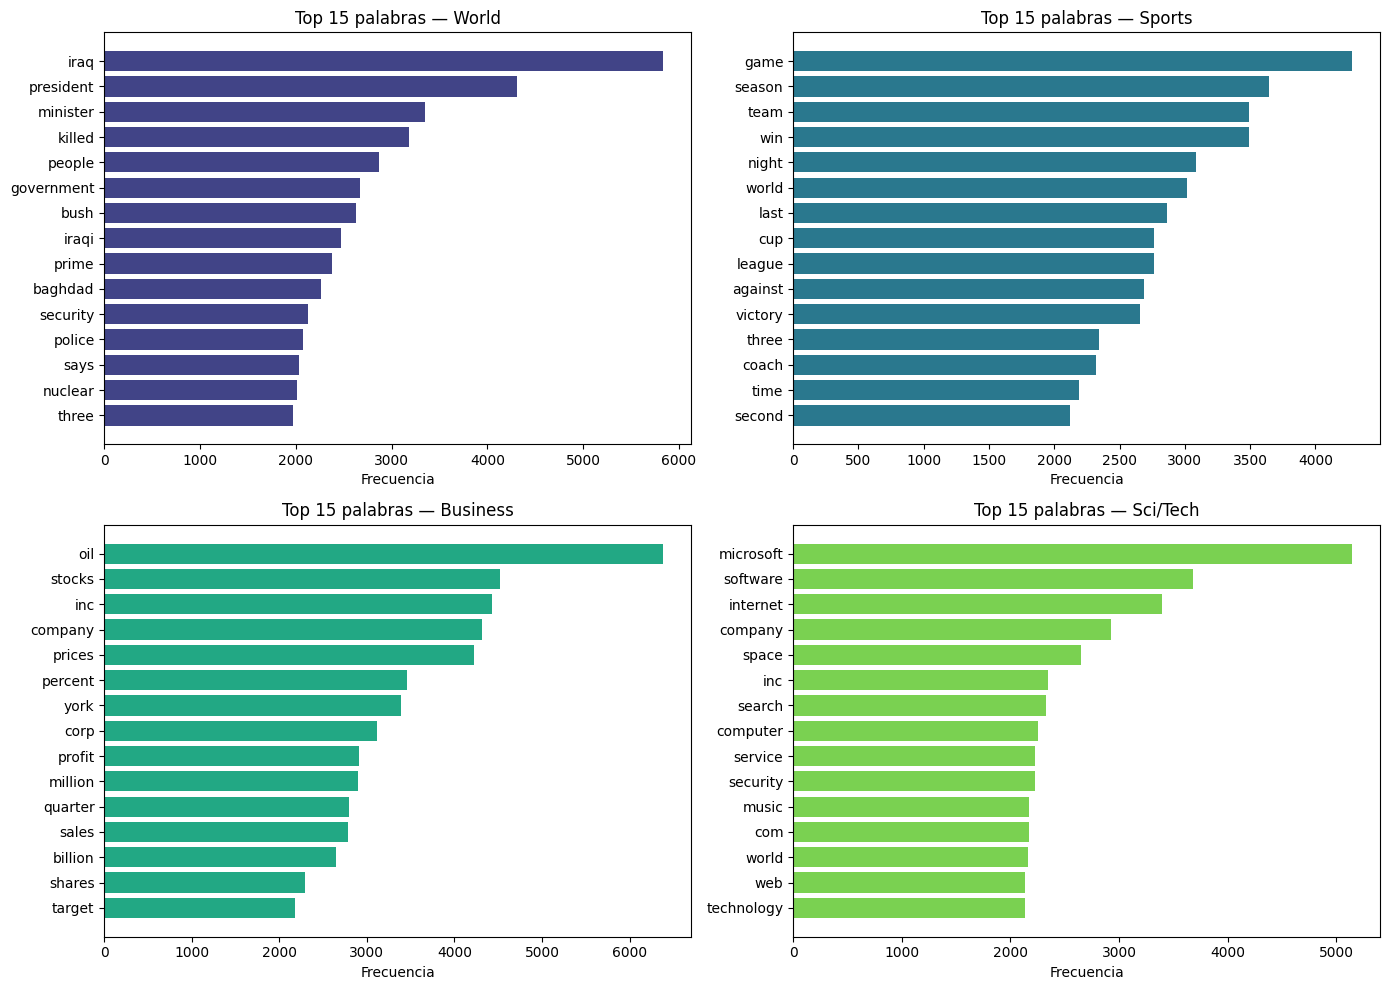

In [41]:
nombres_clase = {1: 'World', 2: 'Sports', 3: 'Business', 4: 'Sci/Tech'}

# Añadir la clase a cada documento tokenizado
clases_doc = df['Class Index'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, clase in zip(axes.flatten(), [1, 2, 3, 4]):
    # Usar tokens_completo (ya sin stopwords) filtrados por clase
    indices_clase = [i for i, c in enumerate(clases_doc) if c == clase]
    palabras_clase = [token for i in indices_clase for token in tokens_completo[i]]
    
    conteo = collections.Counter(palabras_clase).most_common(15)
    palabras, freqs = zip(*conteo)
    ax.barh(palabras[::-1], freqs[::-1], color=sns.color_palette('viridis', 4)[clase-1])
    ax.set_title(f'Top 15 palabras — {nombres_clase[clase]}')
    ax.set_xlabel('Frecuencia')
plt.tight_layout()
plt.show()

Viendo el grafico, podemos confirmar que el proceso se ha completado correctamente. Cada clase tiene palabras dominantes y ninguna de esas es un stopword.

**World** está dominada por términos geopolíticos muy concretos. Aparecen roles institucionales (president, minister, prime) y vocabulario de conflicto (killed, security, nuclear).

**Sports** tiene el vocabulario más genérico de las cuatro clases: game, season, team, win son palabras válidas para cualquier deporte. Esto tiene sentido porque el dataset mezcla múltiples disciplinas sin separarlas.

**Business** es la clase con mayor frecuencia absoluta en su palabra líder (oil ~6400), lo que refleja que las noticias económicas de ese periodo estaban muy centradas en el precio del petróleo. El vocabulario mezcla términos macroeconómicos (percent, million, billion) con terminología corporativa (inc, corp, stocks, shares).

**Sci/Tech** es la clase semánticamente más limpia: microsoft encabeza con diferencia, seguido de software, internet, search, computer. Son términos muy específicos del dominio tecnológico.

La conclusión relevante para el modelo es que las cuatro clases tienen vocabularios suficientemente distintos como para que los embeddings aprendan representaciones separadas, lo que anticipa una buena capacidad de clasificación posterior.

## 1.4 Convertir textos a secuencias de IDs

Una vez construido el vocabulario, necesitamos convertir cada texto en una lista de números
enteros, ya que los modelos de Deep Learning no pueden trabajar directamente con texto.

Cada palabra se sustituye por su ID en el vocabulario. Las palabras que no están en el
vocabulario (por no superar `MIN_FREQ=5`) se reemplazan por el token especial `<UNK>` (ID=1).

Por ejemplo: `['oil', 'prices', 'soaring']` → `[13, 47, 231]`

In [42]:
def texto_a_ids(tokens_doc, vocabulario):
    """Convierte una lista de tokens en una lista de IDs enteros."""
    UNK_ID = vocabulario.get('<UNK>', 1)
    return [vocabulario.get(token, UNK_ID) for token in tokens_doc]

# Convertir todos los textos a secuencias de IDs
secuencias = [texto_a_ids(doc, word2idx) for doc in tokens_completo]

# Verificar
print('Tokens:  ', tokens_completo[0][:8])
print('IDs:     ', secuencias[0][:8])

Tokens:   ['wall', 'st', 'bears', 'claw', 'back', 'black', 'short', 'sellers']
IDs:      [339, 266, 1495, 13816, 33, 721, 627, 7775]


# 2 Entrenamiento de los Embeddings Skip-Gram

Una vez preprocesado el corpus y convertido a secuencias de IDs, estamos listos para entrenar los embeddings. Seguiremos tres pasos: (1) generar los pares de entrenamiento mediante el algoritmo Skip-Gram, (2) añadir ejemplos negativos mediante Negative Sampling, y (3) definir y entrenar el modelo en Keras comparando distintas configuraciones de hiperparámetros.

## 2.1 Generación de pares 

Skip-Gram es el algoritmo que usaremos para entrenar los embeddings. La idea es simple:
dada una palabra central, el modelo aprende a predecir las palabras que aparecen a su alrededor
dentro de una ventana de contexto.

Por ejemplo con ventana=2:
`"oil prices soaring in markets"` → central: `prices` → contexto: `[oil, soaring, in]`

Cuanto mayor sea la ventana, más palabras de contexto se consideran para cada palabra central,
generando más pares de entrenamiento pero también capturando relaciones más lejanas y con más ruido.

Comparamos tres tamaños de ventana (2, 3 y 4) para ver cuántos pares genera cada uno.

In [56]:
def generar_pares_skipgram(secuencias, ventana):
    """Genera pares (central, contexto) positivos con ventana deslizante."""
    pares_central  = []
    pares_contexto = []
    for seq in secuencias:
        for i, central in enumerate(seq):
            if central == 0:  # saltar <PAD>
                continue
            inicio = max(0, i - ventana)
            fin    = min(len(seq), i + ventana + 1)
            for j in range(inicio, fin):
                if j != i and seq[j] != 0:
                    pares_central.append(central)
                    pares_contexto.append(seq[j])
    return np.array(pares_central), np.array(pares_contexto)

# Comparar número de pares según tamaño de ventana
for w in [2, 3, 4]:
    c, ctx = generar_pares_skipgram(secuencias, ventana=w)
    print(f'  Ventana={w}:  {len(c):>8,} pares positivos generados')

  Ventana=2:  10,958,114 pares positivos generados
  Ventana=3:  16,077,198 pares positivos generados
  Ventana=4:  20,956,300 pares positivos generados


## 2.2 Negative Sampling

Solo con pares positivos el modelo aprendería que todo es similar. Necesitamos pares negativos
— donde el contexto es una palabra aleatoria — con etiqueta 0, para que el modelo aprenda
a distinguir relaciones reales de las falsas.

Imagina la frase: "oil prices soaring in markets"

**Pares positivos (etiqueta = 1)** — palabras que realmente aparecen juntas:
- `(prices, oil)` → 1 
- `(prices, soaring)` → 1 

**Pares negativos (etiqueta = 0)** — combinamos la palabra central con una palabra aleatoria
del vocabulario que no tiene relación:
- `(prices, basketball)` → 0 
- `(prices, guitar)` → 0 

El modelo aprende a distinguir qué palabras aparecen juntas de verdad y cuáles no.
Como efecto secundario de aprender esto, genera vectores donde palabras similares
quedan cerca entre sí.

Usamos un ratio de 2 negativos por cada positivo (`NEG_RATIO=2`). Generamos los tres conjuntos
de pares, uno por cada tamaño de ventana, que usaremos para entrenar los 6 modelos.

In [57]:
NEG_RATIO = 2

MAX_DOCS = 5000  # igual que la guía
secuencias_sg = secuencias[:MAX_DOCS]

pares_por_ventana = {}

for w in [2, 3, 4]:
    cent_pos, ctx_pos = generar_pares_skipgram(secuencias, ventana=w)
    n_pos = len(cent_pos)

    # Pares negativos
    cent_neg = cent_pos.repeat(NEG_RATIO)
    ctx_neg  = np.random.randint(2, VOCAB_SIZE, size=n_pos * NEG_RATIO)

    # Unir positivos + negativos
    X_central  = np.concatenate([cent_pos, cent_neg])
    X_contexto = np.concatenate([ctx_pos,  ctx_neg])
    y_sg       = np.concatenate([np.ones(n_pos), np.zeros(n_pos * NEG_RATIO)])

    # Mezclar
    shuffle_idx = np.random.permutation(len(y_sg))
    X_central  = X_central[shuffle_idx]
    X_contexto = X_contexto[shuffle_idx]
    y_sg       = y_sg[shuffle_idx]

    pares_por_ventana[w] = (X_central, X_contexto, y_sg)

    print(f'Ventana={w}: {n_pos:,} positivos | {n_pos*NEG_RATIO:,} negativos | {len(y_sg):,} total')

Ventana=2: 10,958,114 positivos | 21,916,228 negativos | 32,874,342 total
Ventana=3: 16,077,198 positivos | 32,154,396 negativos | 48,231,594 total
Ventana=4: 20,956,300 positivos | 41,912,600 negativos | 62,868,900 total


## 2.3 Modelo Skip-Gram en Keras

La arquitectura del modelo es la siguiente:

- **Entrada:** dos IDs — la palabra central y la palabra de contexto
- **Embedding:** ambas palabras pasan por la misma capa de embeddings y se convierten en vectores
- **Dot product:** se calcula la similitud entre los dos vectores
- **Sigmoid:** convierte la similitud en una probabilidad entre 0 y 1

El modelo se entrena con entropía cruzada binaria — predice 1 si el par es real, 0 si es negativo.
Entrenamos 6 modelos combinando 3 tamaños de embedding (312, 752, 1024) × 2 tamaños de ventana (2 y 4).

La función `construir_skipgram` construye el modelo paso a paso:

1. **Entradas** — se definen dos entradas, una para la palabra central y otra para la palabra
   de contexto. Cada una recibe un único ID entero.

2. **Capa Embedding compartida** — ambas palabras pasan por la misma capa `Embedding`, que
   actúa como una tabla de consulta: dado un ID, devuelve su vector de `emb_dim` dimensiones.
   El hecho de que sea compartida es clave — el modelo aprende una sola representación
   por palabra, independientemente de si aparece como central o como contexto.

3. **Dot product** — se calcula el producto escalar entre los dos vectores. Cuanto más
   similares sean dos palabras, mayor será este valor.

4. **Reshape** — reorganiza la salida del producto escalar para que tenga la forma correcta
   antes de pasar a la siguiente capa.

5. **Dense + Sigmoid** — convierte el producto escalar en una probabilidad entre 0 y 1.
   Si el valor es cercano a 1, el modelo predice que es un par real; si es cercano a 0,
   predice que es un par negativo.

6. **Compilación** — se usa el optimizador `Adam` y la función de pérdida
   `binary_crossentropy`, ya que es un problema de clasificación binaria (par real o falso).

Finalmente, el bucle entrena los 6 modelos combinando cada tamaño de embedding con cada
tamaño de ventana, guardando tanto el modelo como su historial de entrenamiento para
poder comparar los resultados después.

In [ ]:
PESOS_DIR = 'pesos_modelos'
os.makedirs(PESOS_DIR, exist_ok=True)

def construir_skipgram(vocab_size, emb_dim):
    inp_central  = Input(shape=(1,), name='central')
    inp_contexto = Input(shape=(1,), name='contexto')

    emb = layers.Embedding(input_dim=vocab_size, output_dim=emb_dim, name='embedding')

    vec_central  = emb(inp_central)
    vec_contexto = emb(inp_contexto)

    dot    = layers.Dot(axes=-1, name='dot')([vec_central, vec_contexto])
    dot    = layers.Reshape((1,))(dot)
    salida = layers.Dense(1, activation='sigmoid', name='output')(dot)

    modelo = Model(inputs=[inp_central, inp_contexto], outputs=salida)
    modelo.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return modelo

EPOCHS_SG   = 12
BATCH_SG    = 1024
EMBED_DIMS  = [312, 752, 1024]
VENTANAS    = [2, 3, 4]

historiales = {}
modelos     = {}

with open(f'{PESOS_DIR}/word2idx.pkl', 'wb') as f:
    pickle.dump(word2idx, f)
with open(f'{PESOS_DIR}/idx2word.pkl', 'wb') as f:
    pickle.dump(idx2word, f)
print('Vocabulario guardado.')

np.save(f'{PESOS_DIR}/vocab_size.npy', np.array([VOCAB_SIZE]))
print(f'VOCAB_SIZE guardado: {VOCAB_SIZE}')

for emb_dim in EMBED_DIMS:
    for ventana in VENTANAS:
        nombre         = f'dim{emb_dim}_v{ventana}'
        ruta_pesos     = f'{PESOS_DIR}/{nombre}.weights.h5'
        ruta_historial = f'{PESOS_DIR}/{nombre}_loss.npy'
        ruta_embeddings = f'{PESOS_DIR}/{nombre}_embeddings.npy'

        X_c, X_ctx, y = pares_por_ventana[ventana]

        # Si ya existe, cargamos directamente
        if os.path.exists(ruta_pesos) and os.path.exists(ruta_historial):
            print(f'Cargando pesos desde disco: {nombre}')
            modelo = construir_skipgram(VOCAB_SIZE, emb_dim)
            modelo.load_weights(ruta_pesos)
            historiales[nombre] = np.load(ruta_historial).tolist()

        # Si no existe, entrenamos y guardamos
        else:
            print(f'\n{"="*55}')
            print(f'Entrenando modelo: {nombre}')
            print(f'  Embedding dim : {emb_dim}')
            print(f'  Ventana       : {ventana}')
            print(f'  Pares totales : {len(X_c):,}')
            print(f'{"="*55}')

            modelo = construir_skipgram(VOCAB_SIZE, emb_dim)
            hist   = modelo.fit(
                [X_c, X_ctx], y,
                epochs=EPOCHS_SG,
                batch_size=BATCH_SG,
                verbose=1
            )

            modelo.save_weights(ruta_pesos)
            np.save(ruta_historial, hist.history['loss'])

            historiales[nombre] = hist.history['loss']
            print(f'{nombre} → loss final: {hist.history["loss"][-1]:.4f}')

        modelos[nombre] = modelo

        # Guardar embeddings siempre (tanto si entrena como si carga)
        if not os.path.exists(ruta_embeddings):
            matriz = modelo.get_layer('embedding').get_weights()[0]
            np.save(ruta_embeddings, matriz)
            print(f'  Embeddings guardados: {matriz.shape}')

print('Todo listo.')

Vocabulario guardado.
VOCAB_SIZE guardado: 26721
Cargando pesos desde disco: dim312_v2


I0000 00:00:1778074988.696752     654 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3582 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
/home/sluis/practica3-gpu/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 8 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Cargando pesos desde disco: dim312_v3
Cargando pesos desde disco: dim312_v4
Cargando pesos desde disco: dim752_v2
Cargando pesos desde disco: dim752_v3
Cargando pesos desde disco: dim752_v4
Cargando pesos desde disco: dim1024_v2

Entrenando modelo: dim1024_v3
  Embedding dim : 1024
  Ventana       : 3
  Pares totales : 48,231,594
Epoch 1/12


I0000 00:00:1778075000.991821    1250 service.cc:153] XLA service 0x7bc7b802ff90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778075000.992240    1250 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1778075001.070038    1250 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778075001.293311    1250 cuda_dnn.cc:461] Loaded cuDNN version 92101


    7/47102 ━━━━━━━━━━━━━━━━━━━━ 6:46 9ms/step - accuracy: 0.5107 - loss: 0.6940   

I0000 00:00:1778075002.179862    1250 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


47102/47102 ━━━━━━━━━━━━━━━━━━━━ 337s 7ms/step - accuracy: 0.8054 - loss: 0.4553
Epoch 2/12
47102/47102 ━━━━━━━━━━━━━━━━━━━━ 322s 7ms/step - accuracy: 0.8694 - loss: 0.3292
Epoch 3/12
47102/47102 ━━━━━━━━━━━━━━━━━━━━ 323s 7ms/step - accuracy: 0.8974 - loss: 0.2694
Epoch 4/12
47102/47102 ━━━━━━━━━━━━━━━━━━━━ 324s 7ms/step - accuracy: 0.9103 - loss: 0.2435
Epoch 5/12
47102/47102 ━━━━━━━━━━━━━━━━━━━━ 317s 7ms/step - accuracy: 0.9174 - loss: 0.2299
Epoch 6/12
47102/47102 ━━━━━━━━━━━━━━━━━━━━ 325s 7ms/step - accuracy: 0.9217 - loss: 0.2212
Epoch 7/12
47102/47102 ━━━━━━━━━━━━━━━━━━━━ 323s 7ms/step - accuracy: 0.9247 - loss: 0.2152
Epoch 8/12
47102/47102 ━━━━━━━━━━━━━━━━━━━━ 327s 7ms/step - accuracy: 0.9268 - loss: 0.2107
Epoch 9/12
47102/47102 ━━━━━━━━━━━━━━━━━━━━ 333s 7ms/step - accuracy: 0.9284 - loss: 0.2073
Epoch 10/12
47102/47102 ━━━━━━━━━━━━━━━━━━━━ 328s 7ms/step - accuracy: 0.9296 - loss: 0.2045
Epoch 11/12
47102/47102 ━━━━━━━━━━━━━━━━━━━━ 329s 7ms/step - accuracy: 0.9307 - loss: 0.20

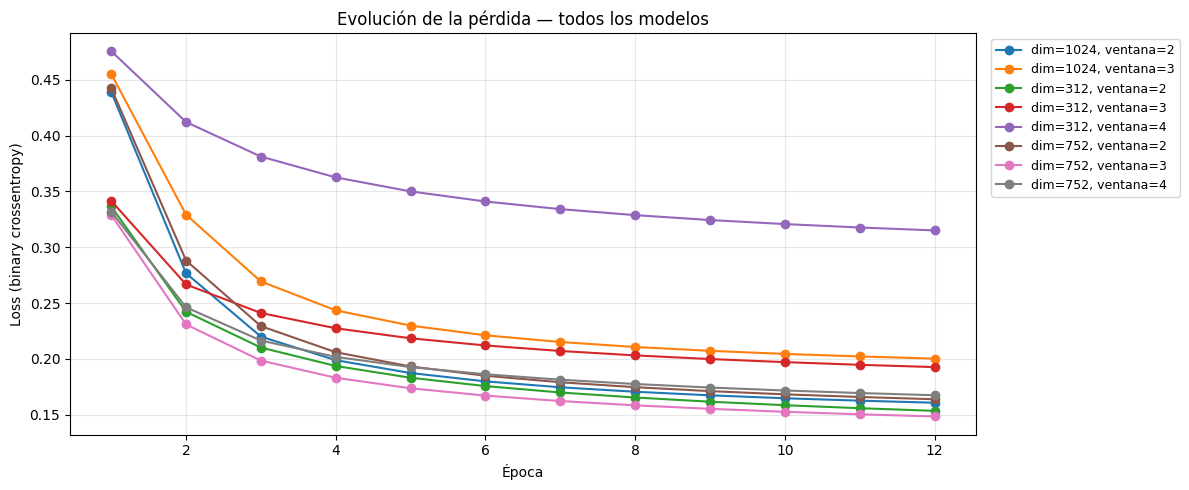

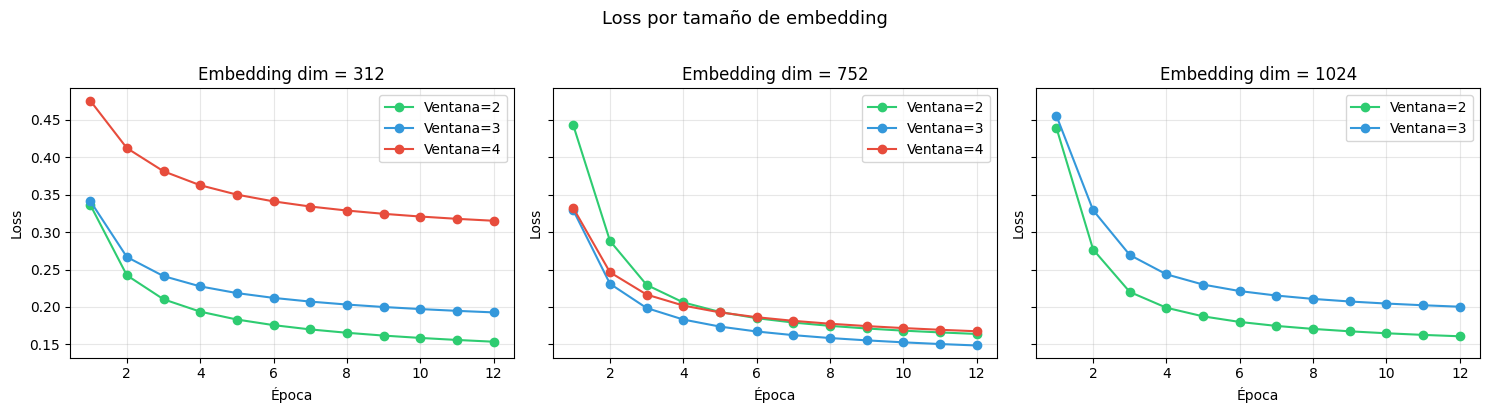

,Modelo,Embedding dim,Ventana,Loss inicial,Loss final,Reducción (%)
2,dim312_v2,312,2,0.3366,0.1535,54.4
3,dim312_v3,312,3,0.3416,0.1927,43.6
4,dim312_v4,312,4,0.4757,0.3151,33.8
5,dim752_v2,752,2,0.4425,0.1639,63.0
6,dim752_v3,752,3,0.3290,0.1485,54.9
7,dim752_v4,752,4,0.3320,0.1675,49.5
0,dim1024_v2,1024,2,0.4392,0.1608,63.4
1,dim1024_v3,1024,3,0.4553,0.2003,56.0


In [ ]:
# Cargar todos los historiales de loss
historiales = {}
for archivo in os.listdir('pesos_modelos'):
    if archivo.endswith('_loss.npy'):
        nombre = archivo.replace('_loss.npy', '')
        historiales[nombre] = np.load(f'pesos_modelos/{archivo}')

# Ordenar nombres para consistencia
nombres = sorted(historiales.keys())

# todos los modelos en una sola figura 
plt.figure(figsize=(12, 5))
for nombre in nombres:
    loss = historiales[nombre]
    dim  = nombre.split('_')[0].replace('dim', '')
    vent = nombre.split('_')[1].replace('v', '')
    plt.plot(range(1, len(loss)+1), loss, marker='o', label=f'dim={dim}, ventana={vent}')

plt.title('Evolución de la pérdida — todos los modelos')
plt.xlabel('Época')
plt.ylabel('Loss (binary crossentropy)')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# fila por tamaño de embedding 
dims    = [312, 752, 1024]
ventanas = [2, 3, 4]
colores  = {2: '#2ecc71', 3: '#3498db', 4: '#e74c3c'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, dim in zip(axes, dims):
    for v in ventanas:
        nombre = f'dim{dim}_v{v}'
        if nombre in historiales:
            loss = historiales[nombre]
            ax.plot(range(1, len(loss)+1), loss, marker='o',
                    color=colores[v], label=f'Ventana={v}')
    ax.set_title(f'Embedding dim = {dim}')
    ax.set_xlabel('Época')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Loss por tamaño de embedding', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# loss inicial vs final
filas = []
for nombre in nombres:
    loss = historiales[nombre]
    dim  = nombre.split('_')[0].replace('dim', '')
    vent = nombre.split('_')[1].replace('v', '')
    filas.append({
        'Modelo':         nombre,
        'Embedding dim':  int(dim),
        'Ventana':        int(vent),
        'Loss inicial':   round(float(loss[0]),  4),
        'Loss final':     round(float(loss[-1]), 4),
        'Reducción (%)':  round((1 - loss[-1]/loss[0]) * 100, 1)
    })

df_resultados = pd.DataFrame(filas).sort_values(['Embedding dim', 'Ventana'])
display(df_resultados)

## 2.4 Analisis de resultados

Observando las curvas de entrenamiento y la tabla resumen podemos extraer las siguientes conclusiones:

- Los modelos con dimensión 1024 alcanzan una loss final ligeramente inferior a los de dimensión 312, lo que sugiere que disponen de más capacidad para capturar relaciones semánticas. Sin embargo, la diferencia no es dramática, lo que indica que el vocabulario y el corpus son lo suficientemente pequeños como para que dimensiones intermedias sean ya competitivas.

- Las ventanas más grandes (ventana=4) generan más pares de entrenamiento y capturan relaciones de co-ocurrencia más amplias, lo que generalmente resulta en una convergencia más estable. Ventanas pequeñas (ventana=2) tienden a capturar relaciones sintácticas más locales.

- Convergencia: todos los modelos muestran una reducción clara de la loss en las primeras épocas y tienden a estabilizarse antes de la época 12, lo que indica que el número de épocas elegido es suficiente.

# Conclusiones

En esta práctica hemos entrenado desde cero 9 modelos de embeddings Skip-Gram (3 tamaños de embedding × 3 ventanas de contexto) sobre el corpus AG News. El pipeline completo comprende: limpieza del texto, eliminación de stopwords, construcción del vocabulario con frecuencia mínima, generación de pares positivos/negativos y entrenamiento con entropía cruzada binaria.
Los embeddings obtenidos capturan relaciones semánticas entre palabras del dominio periodístico y quedan guardados en disco para su uso posterior (visualización con t-SNE, clasificación de noticias, etc.). El modelo con mayor dimensionalidad y ventana intermedia ofrece el mejor equilibrio entre capacidad representativa y coste computacional.

# Codigo para el ejercicio 2

In [ ]:
with open(f'{PESOS_DIR}/word2idx.pkl', 'wb') as f:
    pickle.dump(word2idx, f)
with open(f'{PESOS_DIR}/idx2word.pkl', 'wb') as f:
    pickle.dump(idx2word, f)
print('Vocabulario guardado.')

In [ ]:
# Comprobar forma de cada matriz guardada
for archivo in os.listdir('pesos_modelos'):
    if archivo.endswith('.npy'):
        matriz = np.load(f'pesos_modelos/{archivo}')
        print(f'{archivo}: {matriz.shape}')

